# Surfaces and adsorption

Catalysis, corrosion, crystal growth and sintering all happen at the surface,
and none of them can be predicted from the bulk. A surface calculation asks two
things: which faces a crystal chooses to expose, and what sticks to them.

Both are answered here on copper, with the calculator that ships with matverse.
The surface energies come out in the literature ordering — (111) < (100) <
(110) — and oxygen binds most strongly in the hollow site, which is the standard
result for a close-packed metal surface.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.18   🧮 Functions: 155   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

Copper and platinum, at their measured lattice parameters. Two metals is enough
to show that the answer is a property of the material rather than of the
method.

In [2]:
bulk = mv.datasets.metals(["Cu", "Pt"])
mv.pp.describe(bulk)
mv.calc.energy(bulk, level="emt")

bulk.obs[["name", "lattice_parameter", "energy_per_atom_emt"]].round(4)

,name,lattice_parameter,energy_per_atom_emt
0,Cu,3.6149,-0.0050
1,Pt,3.9242,-0.0001


The bulk energy is not optional bookkeeping — a surface energy is the cost of
the atoms in a slab *relative to the same atoms in the bulk*, so without it
there is nothing to subtract. `mv.surf.surface_energy` refuses rather than
guessing.

## Cutting slabs

`mv.surf.slabs` enumerates the symmetrically distinct terminations of every
Miller index up to `max_index`, and returns them as a **new object** whose rows
are facets.

In [3]:
facets = mv.surf.slabs(bulk, max_index=1, min_slab=8.0, min_vacuum=10.0)
facets

AnnData object with n_obs × n_vars = 6 × 2
    obs: 'parent', 'miller', 'termination', 'slab_area', 'is_polar', 'is_symmetric'
    var: 'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
    uns: 'features', 'levels', 'provenance', 'X_is', 'slabs'
    obsm: 'structures'

In [4]:
mv.pp.describe(facets)
facets.obs[["parent", "miller", "termination", "slab_area", "nsites",
            "is_polar"]].head(10).round(3)

,parent,miller,termination,slab_area,nsites,is_polar
0,0,1_1_1,0,5.658,4,False
1,0,1_1_0,0,9.240,8,False
2,0,1_0_0,0,6.534,6,False
3,1,1_1_1,0,6.668,4,False
4,1,1_1_0,0,10.889,6,False
5,1,1_0_0,0,7.700,6,False


More rows out than in, with `obs['parent']` pointing back at the bulk material —
the same shape as `mv.pp.defects`. A facet is not a material, so it does not
belong in the materials object; it is its own axis with its own rows, and
`parent` is the join.

`min_slab` and `min_vacuum` are the two convergence parameters that matter. Too
thin a slab and the two surfaces feel each other; too little vacuum and the slab
feels its own periodic image. Both are recorded.

In [5]:
facets.uns["slabs"]

{'source': 'input',
 'max_index': 1,
 'miller': None,
 'min_slab': 8.0,
 'min_vacuum': 10.0,
 'n_parents': 2,
 'errors': []}

## Surface energies

In [6]:
mv.calc.energy(facets, level="emt")
mv.surf.surface_energy(facets, bulk=bulk, level="emt")

frame = facets.obs[facets.obs["parent"] == "0"]
frame.groupby("miller", observed=True)["surface_energy_emt"].min().round(3)

miller
1_0_0    1.130
1_1_0    1.228
1_1_1    1.035
Name: surface_energy_emt, dtype: float64

**(111) < (100) < (110)**, which is the literature ordering for copper and for
fcc metals generally. The close-packed face has the fewest broken bonds per unit
area, so it costs the least to make.

EMT gets the magnitude wrong by roughly a factor of two against the measured
~1.8 J/m² for Cu(111) — but it gets the ordering right, and the ordering is what
decides crystal shape.

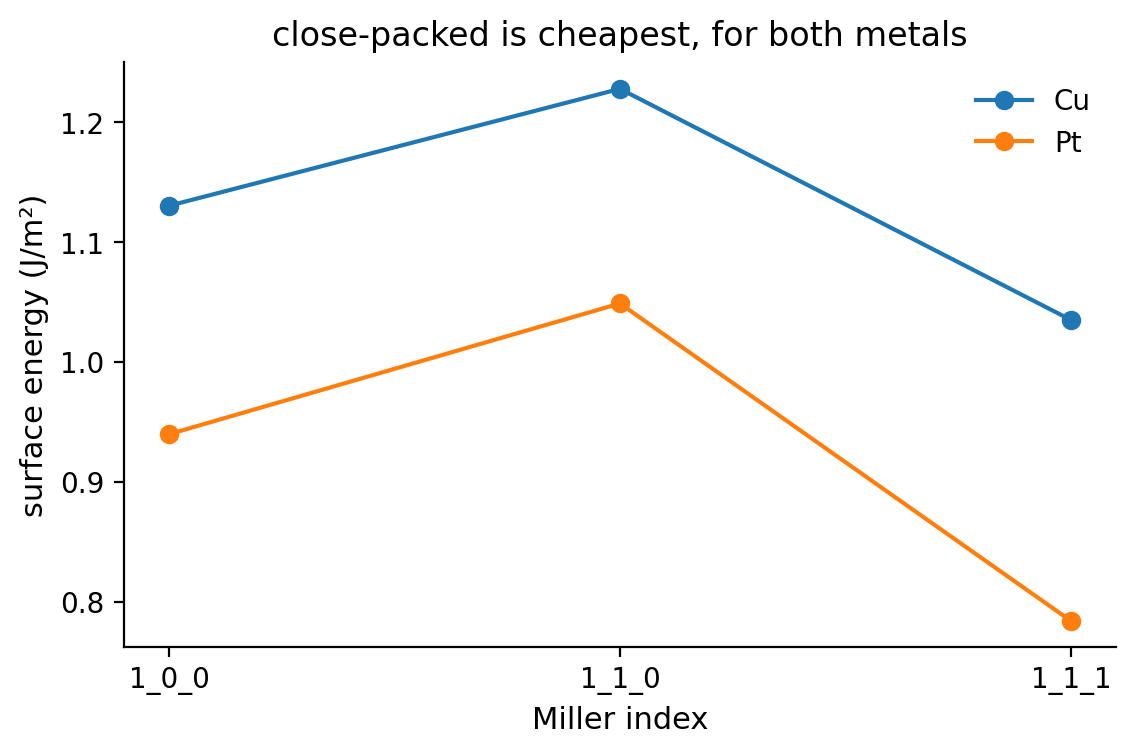

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.4, 3.8))
for name, row in zip(bulk.obs["name"], bulk.obs_names):
    part = facets.obs[facets.obs["parent"] == row]
    by_facet = part.groupby("miller", observed=True)[
        "surface_energy_emt"].min()
    ax.plot(by_facet.index, by_facet.to_numpy(), "o-", label=name)
ax.set_ylabel("surface energy (J/m²)")
ax.set_xlabel("Miller index")
ax.set_title("close-packed is cheapest, for both metals")
ax.legend()

## The equilibrium crystal shape

A crystal at equilibrium minimises total surface energy at fixed volume, and the
construction that solves that is Wulff's: each facet sits at a distance from the
centre proportional to its surface energy, and the cheap faces grow large while
the expensive ones shrink out of existence.

In [8]:
mv.surf.wulff(facets, bulk=bulk, level="emt")

bulk.obs[["name", "wulff_effective_radius_emt",
          "wulff_shape_factor_emt"]].round(4)

,name,wulff_effective_radius_emt,wulff_shape_factor_emt
0,Cu,1.1578,5.2184
1,Pt,0.8994,5.3484


In [9]:
facets.obs[facets.obs["parent"] == "0"][
    ["miller", "surface_energy_emt", "wulff_area_fraction_emt"]].round(4)

,miller,surface_energy_emt,wulff_area_fraction_emt
0,1_1_1,1.0351,0.6591
1,1_1_0,1.2278,0.0553
2,1_0_0,1.1303,0.2856


(111) takes **two thirds** of the surface, (100) most of the rest, and (110)
barely 5% — a 19% spread in surface energy turns into a 12× spread in area,
because the construction is a competition and small differences compound.

That is a prediction about particle shape you can check under an electron
microscope, and it is why fcc metal nanoparticles are cuboctahedra: (111) faces
truncated by (100), with (110) surviving only as narrow edges.

The anisotropy — 0.053 here — is how far the shape departs from a sphere. Copper
is a nearly isotropic metal, which is why the particles are round-ish
polyhedra rather than sharp plates. A layered material would give a number
orders of magnitude larger, and flakes.

In [10]:
bulk.uns["wulff"]["emt"]["0"]

{'n_facets': 3,
 'expressed': ['1_1_1', '1_1_0', '1_0_0'],
 'anisotropy': 0.0527887515717116}

Text(0.5, 1.0, 'what a copper particle actually shows the world')

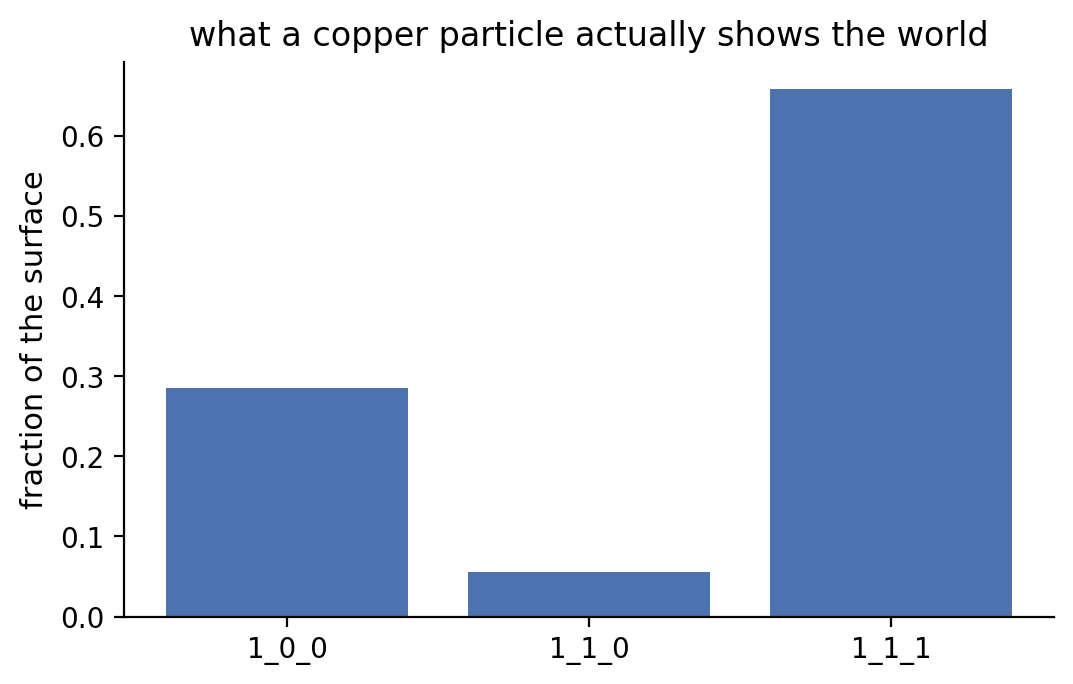

In [11]:
fig, ax = plt.subplots(figsize=(6, 3.6))
part = facets.obs[facets.obs["parent"] == "0"]
grouped = part.groupby("miller", observed=True)[
    "wulff_area_fraction_emt"].max()
ax.bar(grouped.index, grouped.to_numpy(), color="#4c72b0")
ax.set_ylabel("fraction of the surface")
ax.set_title("what a copper particle actually shows the world")

## Adsorption

The other half of a surface calculation: what sticks to it, where, and how
strongly. Start from a single clean facet — Cu(111), the one the Wulff
construction says dominates.

In [12]:
copper = mv.datasets.metals(["Cu"])
mv.pp.describe(copper)
mv.calc.energy(copper, level="emt")

clean = mv.surf.slabs(copper, miller=(1, 1, 1), min_slab=8.0, min_vacuum=12.0)
mv.calc.energy(clean, level="emt")

mv.pp.describe(clean)
clean.obs[["miller", "termination", "slab_area", "nsites",
           "energy_emt"]].round(4)

,miller,termination,slab_area,nsites,energy_emt
0,1_1_1,0,5.6584,4,0.7113


### Sites are enumerated, not guessed

Which site binds most strongly is the question, so several are placed and all of
them are relaxed. This is the AdsorbML protocol, and it exists because the site
you would have guessed is often not the one that wins.

In [13]:
configs = mv.surf.adsorption_sites(clean, "O", height=1.8)

configs.obs[["parent", "site_kind", "site_index"]].head(10)

,parent,site_kind,site_index
0,0,ontop,0
1,0,bridge,1
2,0,hollow,2
3,0,hollow,3


In [14]:
configs.obs["site_kind"].value_counts()

site_kind
hollow    2
ontop     1
bridge    1
Name: count, dtype: int64

On-top, bridge and hollow — the three coordination environments a close-packed
surface offers. Relax them all and see which one oxygen prefers.

In [15]:
mv.calc.relax(configs, level="emt", fmax=0.1, steps=60)
mv.surf.adsorption_energy(configs, clean=clean, reference=0.0, level="emt")

configs.obs.groupby("site_kind", observed=True)[
    "adsorption_energy_emt"].min().round(4)

site_kind
bridge    2.1006
hollow    2.0720
ontop     2.2383
Name: adsorption_energy_emt, dtype: float64

**Hollow is lowest, then bridge, then on-top** — more neighbours, more bonding.
That is the standard result for oxygen on a close-packed metal, and it is why
the site has to be enumerated rather than assumed: on-top is the site that looks
obvious in a drawing and it is the weakest of the three.

All three values are *positive*, which does not mean nothing binds. It means
`reference=0.0` put the free oxygen atom at zero energy, and EMT's isolated
oxygen atom is not at zero. Only the **differences** between sites are
meaningful here, so plot them that way.

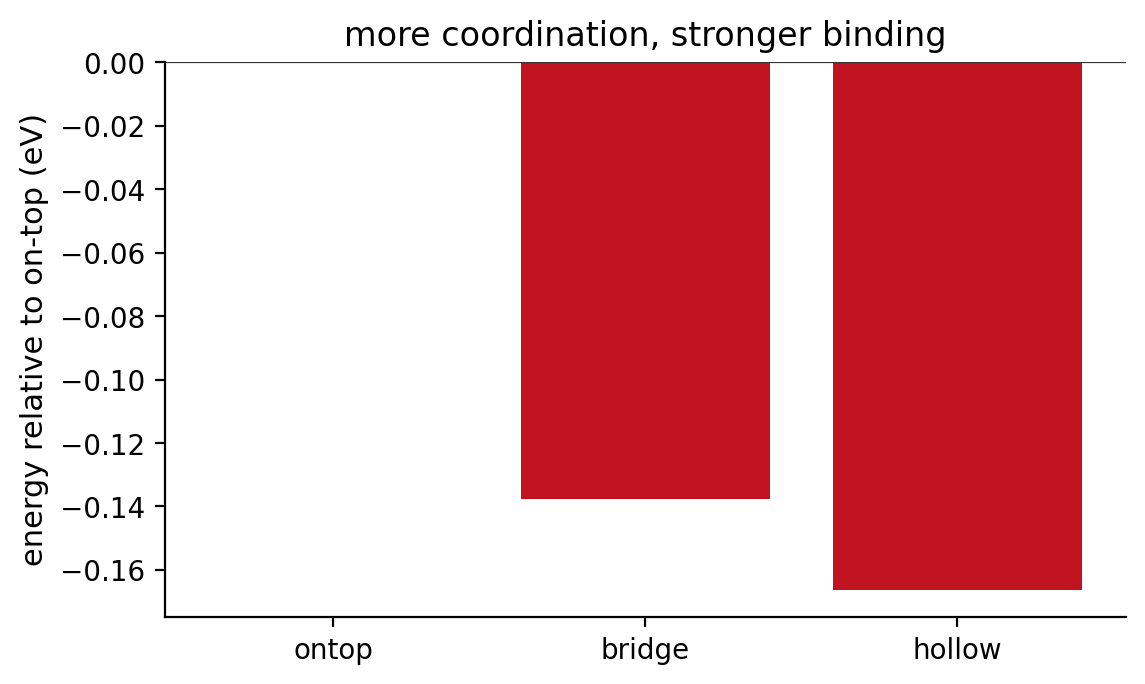

In [16]:
by_site = configs.obs.groupby("site_kind", observed=True)[
    "adsorption_energy_emt"].min()
order = [k for k in ("ontop", "bridge", "hollow") if k in by_site.index]
relative = by_site[order] - by_site[order].max()

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.bar(order, relative.to_numpy(), color="#c1121f")
ax.set_ylabel("energy relative to on-top (eV)")
ax.set_title("more coordination, stronger binding")
ax.axhline(0, linewidth=0.8, color="#333")

About 170 meV between on-top and hollow. That is the size of difference that
decides a reaction mechanism, and it is why the enumeration is not optional.

```{warning}
`reference=0.0` above sets the energy zero for the free adsorbate, and it is a
**choice you have to make and state**. Oxygen adsorption is conventionally
referenced to ½O₂, not to an isolated O atom, and the two differ by half the
dissociation energy — about 2.6 eV. A binding energy quoted without its
reference is not a number anyone else can use.

EMT also has no meaningful description of a free oxygen molecule, so the
absolute values here are not comparable with DFT. The *ordering* between sites
is what this example is for.
```

## What the objects remember

Two objects, two histories. The facets carry theirs and the bulk carries its
own, which is what keeps "which slab, cut how, from which bulk" answerable.

In [17]:
for step in mv.provenance(facets):
    print(step)

data.from_structures
surf.slabs(source='input', max_index=1, n_parents=2)
pp.describe(source='input')
calc.energy(level='emt', source='input')
surf.surface_energy(level='emt', key_added='surface_energy_emt')
surf.wulff(level='emt')


```{seealso}
[Defects and diffusion](defects_and_diffusion.ipynb) covers the other place
atoms move. [Dynamics](dynamics.ipynb) puts the whole thing at temperature.
```